# Phân Tích Churn Khách Hàng Viễn Thông (Telco Customer Churn)
Dự án này thực hiện các bước chuẩn bị dữ liệu, khám phá và trực quan hóa để xác định yếu tố dẫn đến việc rời bỏ của khách hàng.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Import file CSV
df = pd.read_csv('Telco-Customer-Churn.csv')
print("Dữ liệu ban đầu:")
print(df.head())

Dữ liệu ban đầu:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies    

## 1. Chuẩn Bị Dữ Liệu

In [7]:
# Làm sạch dữ liệu
# Xử lý giá trị missing trong TotalCharges (có các khoảng trắng)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# Chuyển đổi SeniorCitizen sang Yes/No
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# Loại bỏ duplicates dựa trên Customer ID
df = df.drop_duplicates(subset=['customerID'])

# Tạo cột mới: Tenure Group
def tenure_group(tenure):
    if tenure < 12:
        return '<12 tháng'
    elif 12 <= tenure <= 36:
        return '12-36'
    else:
        return '>36'
df['Tenure Group'] = df['tenure'].apply(tenure_group)

# Tạo cột mới: Total Services (Số dịch vụ khách hàng đăng ký)
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Đếm dịch vụ: Coi các giá trị khác 'No' và 'No phone/internet service' là có dịch vụ
df['Total Services'] = df[service_cols].apply(lambda x: x.map(lambda val: 0 if val in ['No', 'No phone service', 'No internet service'] else 1)).sum(axis=1)

print("Dữ liệu sau khi làm sạch và thêm cột:")
print(df[['customerID', 'Tenure Group', 'Total Services']].head())

Dữ liệu sau khi làm sạch và thêm cột:
   customerID Tenure Group  Total Services
0  7590-VHVEG    <12 tháng               2
1  5575-GNVDE        12-36               4
2  3668-QPYBK    <12 tháng               4
3  7795-CFOCW          >36               4
4  9237-HQITU    <12 tháng               2


## 2. Khám Phá Dữ Liệu (EDA)

In [8]:
# Churn Rate tổng
total_churn_rate = (df['Churn'] == 'Yes').mean() * 100
print(f"Tỷ lệ Churn tổng thể: {total_churn_rate:.2f}%")

# Churn Rate theo nhóm Tenure Group
churn_by_tenure_group = df.groupby('Tenure Group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print("\nTỷ lệ Churn theo nhóm Tenure:")
print(churn_by_tenure_group)

# Trung bình Tenure theo InternetService
avg_tenure_internet = df.groupby('InternetService')['tenure'].mean()
print("\nTrung bình Tenure theo InternetService:")
print(avg_tenure_internet)

# Mối quan hệ giữa OnlineSecurity và Churn
security_churn = pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index') * 100
print("\nMối quan hệ OnlineSecurity và Churn (%):")
print(security_churn)

Tỷ lệ Churn tổng thể: 26.58%

Tỷ lệ Churn theo nhóm Tenure:
Tenure Group
12-36        25.950329
<12 tháng    48.542274
>36          11.929357
Name: Churn, dtype: float64

Trung bình Tenure theo InternetService:
InternetService
DSL            32.889487
Fiber optic    32.917959
No             30.667763
Name: tenure, dtype: float64

Mối quan hệ OnlineSecurity và Churn (%):
Churn                       No        Yes
OnlineSecurity                           
No                   58.221333  41.778667
No internet service  92.565789   7.434211
Yes                  85.359801  14.640199


## 3. Trực Quan Hóa

/tmp/ipykernel_10192/1628605699.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=security_churn.index, y=security_churn['Yes'], palette='magma')


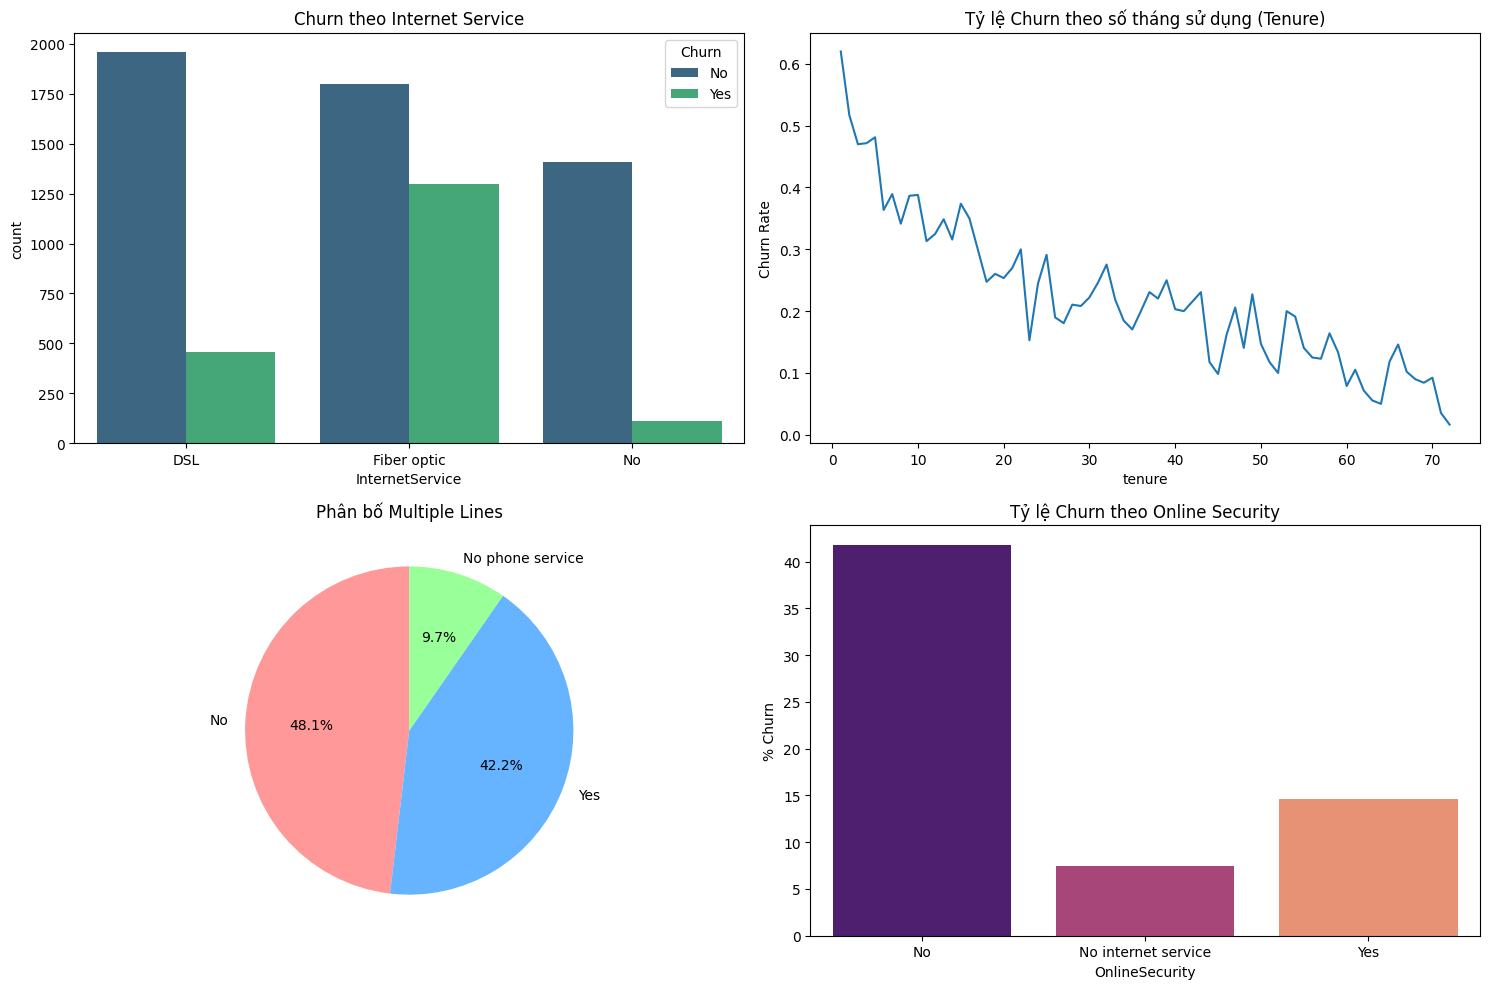

In [9]:
plt.figure(figsize=(15, 10))

# 1. Biểu đồ cột cho Churn theo InternetService
plt.subplot(2, 2, 1)
sns.countplot(x='InternetService', hue='Churn', data=df, palette='viridis')
plt.title('Churn theo Internet Service')

# 2. Biểu đồ đường cho Churn theo Tenure
plt.subplot(2, 2, 2)
tenure_churn = df.groupby('tenure')['Churn'].apply(lambda x: (x == 'Yes').mean()).reset_index()
sns.lineplot(x='tenure', y='Churn', data=tenure_churn)
plt.title('Tỷ lệ Churn theo số tháng sử dụng (Tenure)')
plt.ylabel('Churn Rate')

# 3. Pie chart cho phân bố MultipleLines
plt.subplot(2, 2, 3)
df['MultipleLines'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Phân bố Multiple Lines')
plt.ylabel('')

# 4. Churn theo Online Security
plt.subplot(2, 2, 4)
sns.barplot(x=security_churn.index, y=security_churn['Yes'], palette='magma')
plt.title('Tỷ lệ Churn theo Online Security')
plt.ylabel('% Churn')

plt.tight_layout()
plt.show()

# 5. Huấn luyện Model (Random Forest)


In [11]:
df_model = df.drop(['customerID'], axis=1)
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# 6. đánh giá mô hình

Accuracy: 0.79

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



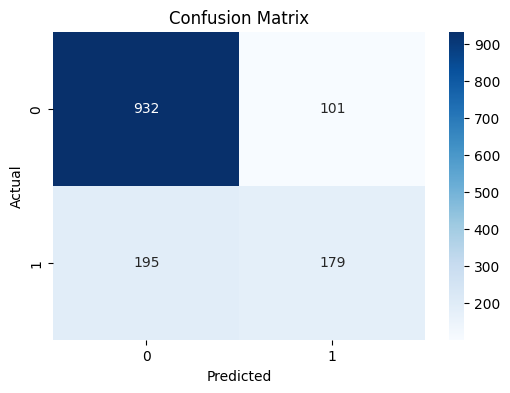

In [13]:
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 4. Rút Ra Insights Và Đề Xuất

### Insights:
- **Yếu tố then chốt:** Khách hàng không đăng ký **OnlineSecurity** có tỷ lệ rời bỏ cao hơn hẳn so với những người có dịch vụ này.
- **Loại Internet:** Người dùng sử dụng **Fiber optic** (Cáp quang) có xu hướng rời bỏ cao hơn DSL, có thể do giá thành hoặc vấn đề kỹ thuật.
- **Thời gian:** Nhóm khách hàng mới (**< 12 tháng**) là nhóm dễ rời bỏ nhất.

### Đề Xuất:
1. **Gói an ninh mạng:** Khuyến mãi hoặc tặng kèm dịch vụ `OnlineSecurity` cho các khách hàng mới để tăng tính gắn kết.
2. **Chăm sóc nhóm Fiber Optic:** Kiểm tra lại chất lượng dịch vụ hoặc cung cấp các gói giảm giá trung thành cho nhóm này.
3. **Chương trình khách hàng mới:** Tập trung các ưu đãi vào 12 tháng đầu tiên để giảm tỷ lệ churn trong giai đoạn nhạy cảm này.